In [1]:
import gzip, pickle
import matplotlib.pyplot as plt
from nilearn.plotting import plot_stat_map
import seaborn as sns
import numpy as np
import pandas as pd
import torch
from torch.nn import functional as F
import nibabel as nib
from neurovlm.data import data_dir
from neurovlm.models import Specter
from neurovlm.resources.loaders import (
    _load_autoencoder, _proj_head_image_infonce, _proj_head_text_infonce, _load_masker
)
from neurovlm import NeuroVLM

from neurovlm.evaluation.notebook_utils import resolve_evaluation_output_dir

evaluation_output_dir = resolve_evaluation_output_dir()
evaluation_output_dir.mkdir(parents=True, exist_ok=True)

In [2]:
specter = Specter("allenai/specter2_aug2023refresh", adapter="adhoc_query", device="cuda")
proj_head_text = _proj_head_text_infonce().to("cuda")
proj_head_image = _proj_head_image_infonce().to("cuda")
autoencoder = _load_autoencoder().to("cuda")
masker = _load_masker()

There are adapters available but none are activated for the forward pass.


In [3]:
# Load network atlases
with gzip.open(data_dir / "networks_arrays.pkl.gz", "rb") as f:
    networks = pickle.load(f)

network_imgs = []
for k in networks.keys():
    for a in networks[k].keys():
        network_imgs.append((k, a, nib.Nifti1Image(networks[k][a]["array"], affine=networks[k][a]["affine"])))

networks = [i for i in network_imgs if i[0] in ["UKBICA", "HCPICA"]]

networks_embed = F.normalize(proj_head_image(torch.load(data_dir / "networks_emb.pt").to("cuda")).detach(), dim=1)

In [4]:

nets = {
    "frontoparietal": (
        "A domain-general control network supporting flexible, goal-directed behavior (task set maintenance, rule switching, "
        "working-memory control, adaptive decision-making). Neuroanatomically centered on dorsolateral prefrontal cortex "
        "(middle frontal gyrus), inferior/superior parietal lobule and intraparietal sulcus, with contributions from dorsal "
        "premotor areas and midline control regions."
    ),
    "language": (
        "A left-lateralized network for speech perception/production and sentence-level comprehension (phonology, syntax, "
        "semantics, speech planning). Typically includes inferior frontal gyrus (Broca’s area: pars opercularis/triangularis), "
        "posterior superior temporal gyrus/sulcus, middle temporal gyrus, anterior temporal lobe, and angular gyrus, with white-matter "
        "support via arcuate/superior longitudinal fasciculus."
    ),
    "memory": (
        "A network supporting episodic memory encoding and retrieval (scene/context construction, recollection, consolidation). "
        "Anchored in the medial temporal lobe (hippocampus, parahippocampal/entorhinal cortex) and strongly coupled to posterior "
        "cingulate/precuneus, retrosplenial cortex, medial prefrontal cortex, and lateral parietal cortex."
    ),
    "motor": (
        "A network for planning, initiation, and execution of voluntary movements (motor sequencing, force control). Core nodes "
        "include primary motor cortex (precentral gyrus), supplementary motor area/pre-SMA, dorsal premotor cortex, with subcortical "
        "loops through basal ganglia and cerebellum."
    ),
    "action-observation": (
        "Often overlapping with the ‘mirror’ system, this network supports action understanding, imitation, and mapping observed actions "
        "to motor representations. Involves inferior frontal gyrus/ventral premotor cortex, inferior parietal lobule (supramarginal/angular), "
        "and posterior superior temporal sulcus as a key visual–biological motion hub."
    ),
    "reward": (
        "A network supporting valuation, reinforcement learning, and motivated behavior (prediction error, incentive salience, reward-guided choice). "
        "Includes ventral striatum/nucleus accumbens, ventromedial/orbitofrontal cortex, anterior cingulate cortex, amygdala, hippocampus, and midbrain "
        "dopaminergic regions (VTA/substantia nigra) with thalamic interactions."
    ),
    "semantic": (
        "A network for conceptual knowledge and meaning integration across modalities (word meaning, category knowledge, semantic control). "
        "Often includes anterior temporal lobe (semantic hub), middle/inferior temporal gyrus, angular gyrus, posterior superior temporal cortex, "
        "and inferior frontal gyrus for controlled semantic retrieval/selection."
    ),
    "sensorimotor": (
        "A network integrating somatosensory input with motor output (tactile perception, proprioception, sensorimotor coordination). "
        "Centered on precentral and postcentral gyri, paracentral lobule, SMA, and secondary somatosensory cortex (parietal operculum), "
        "with contributions from insula and cerebellum for integration and timing."
    ),
    "visual": (
        "A set of occipital and occipito-temporal systems supporting visual perception (low-level feature processing through higher-level object/scene processing). "
        "Includes primary visual cortex (calcarine sulcus/V1), extrastriate areas (V2–V5/MT), lateral occipital cortex, fusiform gyrus, and parahippocampal "
        "place area for scenes, often extending into intraparietal regions for visuospatial processing."
    ),
    "central executive": (
        "A classic control network for working memory, sustained attention, and top-down regulation of thought/action. Neuroanatomically overlaps strongly "
        "with frontoparietal control systems, emphasizing dorsolateral prefrontal cortex and posterior parietal cortex (IPS/SPL), with coordination via dorsal "
        "ACC/pre-SMA in demanding tasks."
    ),
    "cognitive control": (
        "A network implementing top-down control over perception and action (conflict monitoring, inhibition, rule implementation, error processing). "
        "Typically spans dorsolateral and ventrolateral prefrontal cortex, dorsal anterior cingulate cortex/pre-SMA, and posterior parietal cortex, "
        "with basal ganglia contributions for gating and action selection."
    ),
    "default mode": (
        "The default mode network supports internally oriented cognition (mind-wandering, autobiographical memory, self-referential thought, future simulation, "
        "social cognition). Core hubs include posterior cingulate cortex/precuneus and medial prefrontal cortex, with lateral parietal cortex (angular gyrus) "
        "and medial temporal lobe coupling (hippocampus/parahippocampal) depending on memory demands."
    ),
    "executive control": (
        "A network for executive functions like planning, set shifting, maintaining goals, and suppressing distractions. Neuroanatomically overlaps with "
        "frontoparietal/central executive systems (dlPFC and posterior parietal), often coordinating with dorsal ACC/pre-SMA for performance monitoring "
        "and with basal ganglia for action/response selection."
    ),
    "salience": (
        "A network that detects behaviorally relevant stimuli and coordinates switching between internal (DMN) and externally oriented control/attention systems "
        "(rapid orienting, interoception, threat detection). Anchored in anterior insula (especially right), dorsal anterior cingulate cortex, and subcortical "
        "nodes including amygdala, thalamus, and periaqueductal/midbrain regions."
    ),
    "attention": (
        "A broad term for systems supporting selective attention and attentional control (orienting, prioritizing sensory inputs, maintaining vigilance). "
        "Typically spans frontoparietal regions—frontal eye fields, intraparietal sulcus/superior parietal lobule—and interacts with ventral fronto-insular "
        "and temporoparietal regions depending on goal-driven vs. stimulus-driven demands."
    ),
    "ventral attention": (
        "A right-lateralized network for stimulus-driven reorienting to salient or unexpected events (circuit breaker for attention, target detection). "
        "Key nodes include temporoparietal junction, ventral frontal cortex (inferior/middle frontal gyrus), and anterior insula, interacting with sensory "
        "cortex to shift attention rapidly."
    ),
    "dorsal attention": (
        "A bilateral network for goal-directed, top-down allocation of attention (spatial orienting, sustained visuospatial attention, saccade planning). "
        "Centered on intraparietal sulcus/superior parietal lobule and frontal eye fields, with contributions from dorsal premotor regions and visual cortex "
        "for prioritized processing."
    )
}

text = [i + " [SEP] " + nets[i] for i in nets.keys()]
nets = list(nets.keys())


In [5]:
with torch.no_grad():
    labels_emb =  F.normalize(specter(text), dim=1)
    labels_emb = F.normalize(proj_head_text(labels_emb), dim=1)

In [6]:
from nilearn.image import resample_to_img, smooth_img

In [7]:
hcp_networks_orig = [
    i[2] for i in networks if i[0] == "HCPICA"
]

uk_networks_orig = [
    i[2] for i in networks if i[0] == "UKBICA"
]

hcp_networks = [
    masker.transform(
        smooth_img(resample_to_img(i[2], masker.mask_img), fwhm=12)
    ) for i in networks if i[0] == "HCPICA"
]

hcp_networks = np.array(hcp_networks)

uk_networks = [
    masker.transform(
        smooth_img(resample_to_img(i[2], masker.mask_img), fwhm=12)
    ) for i in networks if i[0] == "UKBICA"
]

uk_networks = np.array(uk_networks)
uk_networks = uk_networks[:, 0]

In [30]:
from nilearn.image import smooth_img

def apply_thresh(t):
    x = t.copy()
    x = np.abs(x)
    x = x / np.percentile(x, 99.9, axis=1)[:, None]
    x[x < np.percentile(x, 95.0, axis=1)[:, None]] = 0
    x[x > 1.] = 1.
    #x[x > 0] = 1.
    x = torch.from_numpy(x).float()
    return x

In [31]:
with torch.no_grad():
    t = hcp_networks.copy()
    t = apply_thresh(t).cuda()
    images_hcp_thresh = t.clone()
    hcp_emb = F.normalize(proj_head_image(autoencoder.encoder(t).to("cuda")), dim=1)

    t = uk_networks.copy()
    t = apply_thresh(t).cuda()
    images_uk_thresh = t.clone()
    uk_emb = F.normalize(proj_head_image(autoencoder.encoder(t)).to("cuda"), dim=1)


In [32]:
hcp_cos = hcp_emb @ labels_emb.T
uk_cos = uk_emb @ labels_emb.T
nets = np.array(nets)

In [33]:
def bars(results, lab, i_ax=1):

    i = 0

    for ax, r in zip(axes[:, i_ax], results):
        _labels = [i.split(" (")[0] for i in r[1]]
        _sim = r[2]
        _sim[_sim < 0] = 0.

        # Create color palette based on values
        colors = ['red' if val < 0 else 'steelblue' for val in _sim]
        y_vals = range(0, len(_sim))

        sns.barplot(y=y_vals, x=_sim, orient="h", ax=ax,
                    hue=y_vals, palette=colors, alpha=0.8, legend=False)

        for patch, _label in zip(ax.patches, _labels):
            y0 = patch.get_y()
            h = patch.get_height()
            y_top = y0 + h
            ax.annotate(
                _label,
                (0.01, y_top-.1),
                xytext=(0, 0),
                textcoords="offset points",
                ha="left",
                va="bottom",
                fontsize=9,
            )
        if i == 0:
             ax.spines[['bottom', 'right', 'left']].set_visible(False)
             ax.yaxis.set_visible(False)
             ax.xaxis.set_visible(False)
             ax.set_title(lab)
        elif i < 7:
            ax.axis("off")
        else:
            ax.spines[['top', 'right', 'left']].set_visible(False)
            ax.yaxis.set_visible(False)
            ax.set_xlabel("Cosine Similarity")  # Changed from set_ylabel

        ax.set_xlim(0, 0.5)
        i += 1

In [34]:
nets_ref = [
    "visual",
    "language",
    "sensorimotor",
    #"motor",
    "default mode",
    "frontoparietal",
    # "semantic",
    # "action-observation",
    # "motor"
]
lu_hcp = {}
pairs = list(zip(nets[hcp_cos.argmax(dim=1).cpu().numpy()], hcp_cos.max(dim=1).values))

for ref in nets_ref:
    lu_hcp[ref] = (None, None)

for idx in range(len(pairs)):
    sim = float(pairs[idx][1])
    ref = str(pairs[idx][0])
    if ref in nets_ref and lu_hcp[ref][0] is None:
        lu_hcp[ref] = (idx, sim)
    elif ref in nets_ref and lu_hcp[ref][0] < sim:
        lu_hcp[ref] = (idx, sim)

lu_hcp

{'visual': (2, 0.18646970391273499),
 'language': (16, 0.4264260232448578),
 'sensorimotor': (8, 0.29649585485458374),
 'default mode': (1, 0.4972994029521942),
 'frontoparietal': (4, 0.1346624493598938)}

In [35]:
lu_uk = {}
pairs = list(zip(nets[uk_cos.argmax(dim=1).cpu().numpy()], uk_cos.max(dim=1).values))

for ref in nets_ref:
    lu_uk[ref] = (None, None)

for idx in range(len(pairs)):
    sim = float(pairs[idx][1])
    ref = str(pairs[idx][0])

    if ref in nets_ref and lu_uk[ref][0] is None:
        lu_uk[ref] = (idx, sim)
    elif ref in nets_ref and lu_uk[ref][0] < sim:
        lu_uk[ref] = (idx, sim)

lu_uk

{'visual': (1, 0.5442047715187073),
 'language': (12, 0.3971053957939148),
 'sensorimotor': (10, 0.30796346068382263),
 'default mode': (6, 0.41000816226005554),
 'frontoparietal': (4, 0.16889816522598267)}

In [36]:
results_hcp = []
for i in nets_ref:
    inds = hcp_cos[lu_hcp[i][0]].argsort(descending=True)[:5].cpu().numpy()
    results_hcp.append((
        images_hcp_thresh[lu_hcp[i][0]], nets[inds], hcp_cos[lu_hcp[i][0]][inds].cpu().numpy(), hcp_networks_orig[lu_hcp[i][0]]
    ))

results_uk = []
for i in nets_ref:
    inds = uk_cos[lu_uk[i][0]].argsort(descending=True)[:5].cpu().numpy()
    results_uk.append((
        images_uk_thresh[lu_uk[i][0]], nets[inds], uk_cos[lu_uk[i][0]][inds].cpu().numpy(), uk_networks_orig[lu_uk[i][0]]
    ))

In [51]:
nvlm = NeuroVLM(device="cuda")

def print_network_text(results, label):
    imgs = torch.vstack([r[0] for r in results])
    names = list(nets_ref[:len(imgs)])

    # Match nvlm.brain(img).generate_text preprocessing, then run generation as one batch.
    generated = nvlm.brain(imgs).generate_text(
        seed=123,
        basis="network",
        canonical_basis="all",
        do_sample=False,
        num_beams=10,
        max_new_tokens=128,
        projection_temp=0.05,
        repetition_penalty=1.1,
    )
    generated = [generated] if isinstance(generated, str) else list(generated)

    print(f"\n{label}\n" + "=" * len(label))
    for name, result, text_out in zip(names, results, generated):
        top_labels = ", ".join(map(str, result[1]))
        print(f"\n{name}")
        # print(f"retrieval top-5: {top_labels}")
        print(text_out)


print_network_text(results_hcp, "HCP ICA network text")
print_network_text(results_uk, "UK Biobank ICA network text")



HCP ICA network text

visual
[NETWORK]Visual Network
This network is broadly associated with the processing of visual information. It includes the occipital, temporal, and parietal cortices. Its activity is generally linked to the detection and organization of visual features. It is often described as a central hub for visual perception.

language
[NETWORK]Language Network
The language network includes inferior frontal gyrus, angular gyrus, middle temporal gyrus, and inferior parietal lobule. It is commonly associated with syntactic, semantic, and phonological processing. The network is often described as central to language comprehension and production.

sensorimotor
[NETWORK]Sensorimotor Network
The sensorimotor network includes primary somatosensory cortex, primary motor cortex, premotor cortex, supplementary motor area, parietal prefrontal cortex, and posterior parietal cortex. It is broadly associated with bodily sensation, movement, and interaction with the environment.

default

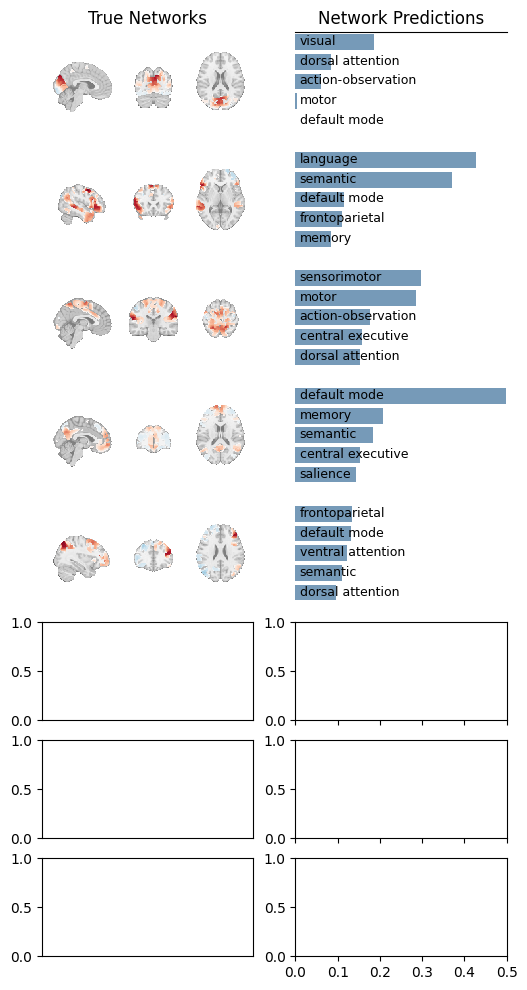

In [54]:

fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(6, 12), sharex="col")

# Barplots
bars([i for idx, i in enumerate(results_hcp)], "Network Predictions", i_ax=1)

# Network images
imgs = [i[-1] for i in results_hcp]

first = True
for ax, img in zip(axes[:, 0], imgs):

    plot_stat_map(img, colorbar=False, draw_cross=False, annotate=False, axes=ax)

    ax.set_yticks([])
    ax.set_xticks([])

    if first:
        ax.set_title("True Networks")
    first = False

plt.savefig(evaluation_output_dir / "clip_ica_hcp.svg", dpi=300)

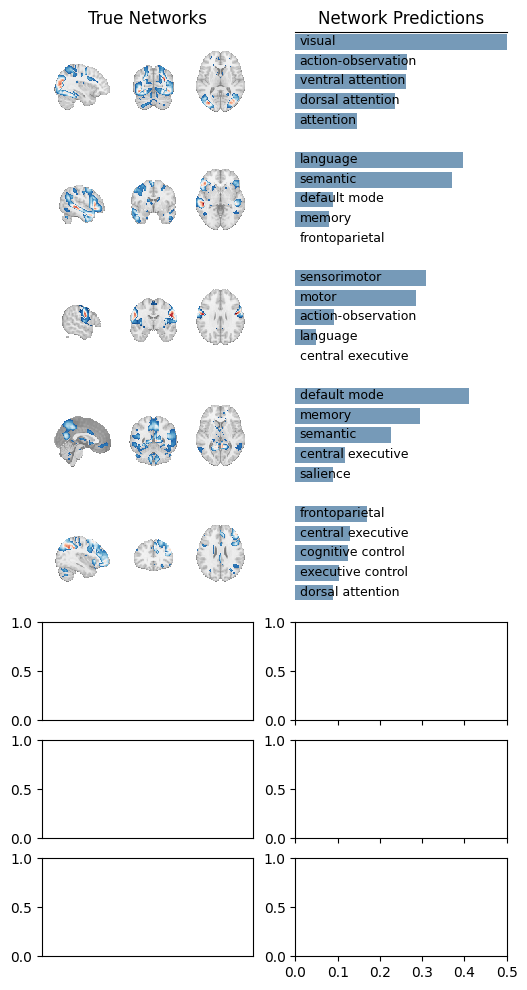

In [59]:
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(6, 12), sharex="col")

# Barplots
bars([i for idx, i in enumerate(results_uk)], "Network Predictions", i_ax=1)

# Network images
imgs = [i[-1] for i in results_uk]

first = True
for ax, img in zip(axes[:, 0], imgs):

    plot_stat_map(img, colorbar=False, draw_cross=False, annotate=False, axes=ax)

    ax.set_yticks([])
    ax.set_xticks([])

    if first:
        ax.set_title("True Networks")
    first = False

plt.savefig(evaluation_output_dir / "clip_ica_uk.svg", dpi=300)